# MORPHEUS — Initial Modeling

## 1. Modeling scope and workflow

This notebook develops the first supervised modeling stage for the MORPHEUS project using the modelable cohort, defined as observations with an observed `short_sleep` target.

Its role is not to rebuild dataset assembly or repeat exploratory analysis. Instead, it translates the analytical decisions established in `01_eda.ipynb` into a first modeling workflow that is reproducible, defensible, and compatible with the reusable MARS infrastructure.

Within this notebook:

- feature roles defined during EDA are treated as the current working specification
- `sleep_hours_weekday` remains excluded from modeling due to structural leakage
- preprocessing decisions may be reused from MARS where appropriate
- model-specific pipelines may still be built directly in sklearn when that is cleaner than forcing a single preprocessing recipe across all models

This notebook should therefore be read as the bridge between EDA conclusions and the first benchmarkable modeling baseline, not as a replacement for analytical reasoning.

## 2. Analytical objective and prediction target

The modeling task is formulated as a binary classification problem in which the target variable is `short_sleep`.

In this project, `short_sleep = 1` indicates that a participant reports sleeping fewer than 7 hours on weekdays or workdays, whereas `short_sleep = 0` indicates 7 hours or more. This threshold is analytically useful because it operationalizes insufficient weekday sleep in a simple and interpretable way.

The goal is not to produce a clinical diagnostic tool. Instead, the purpose of the modeling stage is to evaluate whether a combination of demographic, behavioral, anthropometric, cardiovascular, and sleep-related variables can help identify a meaningful signal associated with short sleep in a real-world health dataset.

This framing preserves the distinction between predictive modeling and clinical inference. The output of the models should therefore be interpreted as a probabilistic signal within the limitations of the available NHANES-derived variables, rather than as a direct medical conclusion.

## 3. Modeling cohort and feature specification

This notebook operates on the modelable cohort only, that is, observations with an observed `short_sleep` target.

The complete assembled dataset remains useful for structural understanding and data provenance, but supervised modeling requires restricting the workflow to rows in which the target is observed. This distinction was established during EDA and is preserved here.

Feature roles are inherited from the analytical review performed in `01_eda.ipynb`. Variables were provisionally grouped into numeric features, categorical features, and likely-drop variables based on missingness, interpretability, semantic proximity to the outcome, and first-pass modeling usefulness.

A critical exclusion remains in force throughout the notebook: `sleep_hours_weekday`, the source variable used to derive the target, must not enter the predictive feature space because doing so would introduce structural leakage.

## 4. Imports and setup

This section loads the libraries and reusable project modules required for the first modeling workflow.

The intention is to keep the notebook lightweight and explicit. Reusable logic that already belongs to MARS should be imported rather than rewritten here, while model-specific benchmarking logic may still be implemented directly in the notebook when that keeps the workflow clearer and more flexible.

In [4]:
# Standard library
from pathlib import Path
import sys

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay

# Make project src importable from the notebook
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# MARS utilities
from src.utils.config import load_and_validate_config
from src.data.io import load_dataset
from src.data.split import split_features_target, make_train_test_split
from src.preprocessing.typing import get_target_column, get_feature_groups
from src.preprocessing.cleaning import drop_columns
from src.preprocessing.pipeline_builder import build_preprocessor

## 5. Data loading and configuration handshake

This section connects the modeling notebook with the reusable project infrastructure.

The assembled dataset is loaded from disk, the project configuration is read from `config.yaml`, and the current feature specification is recovered through MARS utilities. This ensures that the notebook does not silently drift away from the decisions already formalized during EDA.

At this stage, the objective is not yet to train models, but to verify that the declared target, drop columns, and feature groups are internally consistent and usable for downstream modeling.

### 5.1 Load configuration and assembled dataset

In [7]:
config = load_and_validate_config(PROJECT_ROOT / "configs" / "config.yaml")

data_path = PROJECT_ROOT / config["data"]["input_path"]
df = load_dataset(data_path, file_type=config["data"]["file_type"])

print("Config loaded successfully.")
print(f"Resolved data path: {data_path}")
print(f"Dataset shape: {df.shape}")

Config loaded successfully.
Resolved data path: F:\DOCUMENTOS\CIENCIA DE DATOS\portfolio-data-science\morpheus-sleep-health-ml\data\processed\nhanes_sleep_master_v1.csv
Dataset shape: (10195, 47)


### 5.2 Recover target and declared feature groups

In [8]:
target_col = get_target_column(config)
feature_groups = get_feature_groups(df, config)

numeric_features = feature_groups["numeric_features"]
categorical_features = feature_groups["categorical_features"]
drop_cols = config.get("drop_columns", [])

print(f"Target: {target_col}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Declared drop columns ({len(drop_cols)}): {drop_cols}")

Target: short_sleep
Numeric features (10): ['sleep_hours_weekend', 'age_years', 'income_to_poverty_ratio', 'weight_kg', 'height_cm', 'body_mass_index', 'waist_circumference_cm', 'sedentary_minutes', 'systolic_bp_mean', 'diastolic_bp_mean']
Categorical features (11): ['trouble_sleeping', 'told_doctor_sleep_disorder', 'snoring_frequency', 'sex', 'race_ethnicity', 'education_level', 'smoked_100_cigarettes_lifetime', 'alcohol_lifetime_12_drinks', 'alcohol_frequency', 'vigorous_activity', 'moderate_activity']
Declared drop columns (25): ['participant_id', 'sleep_hours_weekday', 'told_doctor_trouble_sleeping', 'systolic_bp_1', 'diastolic_bp_1', 'systolic_bp_2', 'diastolic_bp_2', 'systolic_bp_3', 'diastolic_bp_3', 'current_smoking_frequency', 'alcohol_past_year_12_drinks', 'drinks_per_day', 'vigorous_activity_days', 'vigorous_activity_minutes', 'moderate_activity_days', 'moderate_activity_minutes', 'phq_little_interest', 'phq_feeling_down', 'phq_sleep_problems', 'phq_low_energy', 'phq_appetit

### 5.3 Apply declared exclusions

In [9]:
df_model = drop_columns(df, drop_cols)

print(f"Original dataset shape: {df.shape}")
print(f"Post-drop dataset shape: {df_model.shape}")

dropped_now = [col for col in drop_cols if col not in df_model.columns]
print(f"Columns removed ({len(dropped_now)}): {dropped_now}")

Original dataset shape: (10195, 47)
Post-drop dataset shape: (10195, 22)
Columns removed (25): ['participant_id', 'sleep_hours_weekday', 'told_doctor_trouble_sleeping', 'systolic_bp_1', 'diastolic_bp_1', 'systolic_bp_2', 'diastolic_bp_2', 'systolic_bp_3', 'diastolic_bp_3', 'current_smoking_frequency', 'alcohol_past_year_12_drinks', 'drinks_per_day', 'vigorous_activity_days', 'vigorous_activity_minutes', 'moderate_activity_days', 'moderate_activity_minutes', 'phq_little_interest', 'phq_feeling_down', 'phq_sleep_problems', 'phq_low_energy', 'phq_appetite_problems', 'phq_feeling_bad_about_self', 'phq_trouble_concentrating', 'phq_slow_or_restless', 'phq_self_harm_thoughts']


### 5.4 Verify the post-drop modeling specification

In [10]:
expected_columns = {target_col, *numeric_features, *categorical_features}
actual_columns = set(df_model.columns)

missing_expected = sorted(expected_columns - actual_columns)
unexpected_kept = sorted(actual_columns - expected_columns)

print(f"Expected modeling columns (including target): {len(expected_columns)}")
print(f"Actual columns after declared drops: {len(actual_columns)}")

if missing_expected:
    print(f"Missing expected columns: {missing_expected}")
else:
    print("No expected columns are missing after the declared drops.")

if unexpected_kept:
    print(f"Columns still present but not declared in target/features: {unexpected_kept}")
else:
    print("No undeclared columns remain after the declared drops.")

Expected modeling columns (including target): 22
Actual columns after declared drops: 22
No expected columns are missing after the declared drops.
No undeclared columns remain after the declared drops.


## 6. Modelable cohort extraction

Only observations with an observed target can contribute to supervised learning. For that reason, the workflow now restricts the dataset to the modelable cohort, defined as rows with non-missing `short_sleep`.

This step is not a data cleaning convenience but a modeling requirement. It aligns the notebook with the analytical distinction already established during EDA between the full assembled cohort and the subset that can actually be used for training and evaluation.

### 6.1 Restrict the dataset to the modelable cohort

In [11]:
df_modelable = df_model[df_model[target_col].notna()].copy()

print(f"Post-drop dataset shape: {df_model.shape}")
print(f"Modelable cohort shape: {df_modelable.shape}")
print(f"Rows excluded due to missing target: {df_model.shape[0] - df_modelable.shape[0]}")

Post-drop dataset shape: (10195, 22)
Modelable cohort shape: (7288, 22)
Rows excluded due to missing target: 2907


### 6.2 Inspect target prevalence in the modelable cohort

In [12]:
target_counts = (
    df_modelable[target_col]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

target_counts["percentage"] = (
    df_modelable[target_col]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .values
)

target_counts

,count,percentage
short_sleep,,
0.0,4804,65.92
1.0,2484,34.08


The modelable cohort contains 7,288 observations with an observed `short_sleep` target. Class prevalence is moderately imbalanced, with short sleepers representing roughly one third of the available sample.

This class distribution is not extreme, but it is sufficiently asymmetric to justify a stratified train-test split and the use of evaluation metrics that go beyond raw accuracy alone.

## 7. Final feature space before splitting

Before any train-test split is performed, the declared drop columns are removed and the modeling feature space is fixed according to the current analytical specification.

This step is important for two reasons. First, it ensures that variables excluded for leakage, redundancy, or weak provisional utility do not silently remain in the dataset. Second, it creates a transparent handoff from analytical reasoning to operational modeling.

The resulting design matrix at this point should be understood as the first defendable feature space for benchmarking, not necessarily as the final and immutable version of the project.

### 7.1 Define the modeling matrix and target vector

In [13]:
X, y = split_features_target(df_modelable, target_col)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target name: {y.name}")

X shape: (7288, 21)
y shape: (7288,)
Target name: short_sleep


### 7.2 Verify the final feature matrix against the declared specification

In [14]:
expected_feature_columns = numeric_features + categorical_features
actual_feature_columns = X.columns.tolist()

missing_in_X = sorted(set(expected_feature_columns) - set(actual_feature_columns))
unexpected_in_X = sorted(set(actual_feature_columns) - set(expected_feature_columns))

print(f"Declared feature columns: {len(expected_feature_columns)}")
print(f"Actual columns in X: {len(actual_feature_columns)}")

if missing_in_X:
    print(f"Missing columns in X: {missing_in_X}")
else:
    print("All declared feature columns are present in X.")

if unexpected_in_X:
    print(f"Unexpected columns in X: {unexpected_in_X}")
else:
    print("No undeclared columns are present in X.")

Declared feature columns: 21
Actual columns in X: 21
All declared feature columns are present in X.
No undeclared columns are present in X.


### 7.3 Summarize the final feature space

In [15]:
feature_space_summary = pd.DataFrame(
    {
        "feature_group": ["numeric", "categorical", "total"],
        "n_features": [
            len(numeric_features),
            len(categorical_features),
            X.shape[1],
        ],
    }
)

feature_space_summary

,feature_group,n_features
0,numeric,10
1,categorical,11
2,total,21


## 8. Train-test split strategy

This section creates the holdout partition used for the first modeling benchmark.

The split is stratified by the target so that the prevalence of short sleep remains broadly stable across training and test sets. This preserves comparability across partitions and reduces the risk of drawing misleading conclusions from an unrepresentative test sample.

From this point onward, all preprocessing steps that learn from the data must be fit on the training set only and then applied to the test set.

### 8.1 Create the train-test split

In [16]:
X_train, X_test, y_train, y_test = make_train_test_split(
    X,
    y,
    test_size=config["split"]["test_size"],
    random_state=config["split"]["random_state"],
    stratify=config["split"]["stratify"],
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5830, 21)
X_test shape: (1458, 21)
y_train shape: (5830,)
y_test shape: (1458,)


### 8.2 Check target prevalence across train and test sets

In [17]:
target_distribution_split = pd.DataFrame(
    {
        "train_count": y_train.value_counts().sort_index(),
        "test_count": y_test.value_counts().sort_index(),
        "train_pct": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
        "test_pct": y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
    }
)

target_distribution_split.index.name = target_col
target_distribution_split

,train_count,test_count,train_pct,test_pct
short_sleep,,,,
0.0,3843,961,65.92,65.91
1.0,1987,497,34.08,34.09


### 8.3 Interpretation of the slipt balance

The stratified split preserves the target distribution closely across training and test partitions, which supports a fair first benchmark under a stable class prevalence.

This is an important methodological safeguard because it reduces the chance that downstream performance differences are driven by an avoidable imbalance between partitions rather than by the models themselves.

## 9. Baseline preprocessing philosophy

The project already contains a reusable preprocessing layer within MARS, and this notebook reuses that infrastructure where it remains appropriate.

At the same time, the goal of this notebook is not to force every model through a single universal preprocessing recipe. The preprocessing settings currently declared in the project configuration are therefore treated as a baseline operational recipe for the first benchmark, especially for the linear baseline model.

More flexible or model-specific preprocessing decisions may still be introduced later when a single shared recipe would become unnecessarily rigid.

### 9.1 Build the baseline preprocessor from MARS

In [18]:
baseline_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config=config,
)

baseline_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## 10. Model 1 — Logistic regression baseline

Logistic regression is included as the primary linear baseline for the project.

Its value is not limited to raw predictive performance. Because it provides a relatively interpretable probabilistic model, it offers a useful reference for understanding how much predictive structure can already be captured through a linear decision boundary after standard preprocessing.

Even if more flexible models ultimately outperform it, logistic regression remains an important benchmark because it sets a disciplined lower bound for the modeling task.

### 10.1 Build the logistic regression baseline pipeline

In [20]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

### 10.2 Fit the logistic regression baseline

In [21]:
logreg_pipeline.fit(X_train, y_train)

print("Logistic regression baseline fitted successfully.")

Logistic regression baseline fitted successfully.


### 10.3 Generate test predictions and probabilities

In [22]:
y_test_pred_logreg = logreg_pipeline.predict(X_test)
y_test_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Predictions shape:", y_test_pred_logreg.shape)
print("Probabilities shape:", y_test_proba_logreg.shape)

Predictions shape: (1458,)
Probabilities shape: (1458,)


### 10.4 Baseline interpretation

The logistic regression baseline provides a credible first reference point for the modeling task. Its overall performance suggests that the current feature space contains a meaningful signal for predicting short sleep, even under a relatively simple and interpretable linear classifier.

The diagnostic outputs point to a consistent pattern. Discrimination is moderate rather than strong, but clearly above chance. The precision-recall behavior indicates that the model captures useful signal for the positive class, while the calibration curve suggests that predicted probabilities remain reasonably aligned with observed outcome frequencies across much of the probability range.

At the same time, the confusion matrix shows that the default classification threshold leads to a fairly conservative positive-class assignment. False positives remain limited, but the model still misses a substantial share of true short sleepers. This means that the main limitation of the baseline is not the total absence of signal, but a trade-off in which recall for the positive class remains somewhat constrained under the default decision rule.

Taken together, these results make logistic regression a defensible and informative baseline, even if more flexible models may later improve recall or overall discrimination.

In [23]:
logreg_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_logreg),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_logreg),
    "precision": precision_score(y_test, y_test_pred_logreg),
    "recall": recall_score(y_test, y_test_pred_logreg),
    "f1": f1_score(y_test, y_test_pred_logreg),
    "roc_auc": roc_auc_score(y_test, y_test_proba_logreg),
    "pr_auc": average_precision_score(y_test, y_test_proba_logreg),
    "brier_score": brier_score_loss(y_test, y_test_proba_logreg),
}

logreg_metrics_df = (
    pd.Series(logreg_metrics, name="logistic_regression")
    .round(4)
    .to_frame()
)

logreg_metrics_df

,logistic_regression
accuracy,0.7695
balanced_accuracy,0.6999
precision,0.7539
recall,0.4809
f1,0.5872
roc_auc,0.7754
pr_auc,0.7025
brier_score,0.1697


### 10.5 First reading of the baseline metric table

The logistic regression baseline provides the first empirical reference point for the modeling task. At this stage, the objective is not to declare the model satisfactory or unsatisfactory in isolation, but to understand how much predictive signal can already be extracted from the current feature space using a relatively simple and interpretable classifier.

Particular attention should be paid to the relationship between recall, precision, ROC AUC, PR AUC, and Brier score. Together, these metrics indicate not only whether the model can discriminate between classes, but also whether it behaves in a reasonably balanced and probabilistically coherent way.

### 10.6 Confusion matrix for the logistic regression baseline

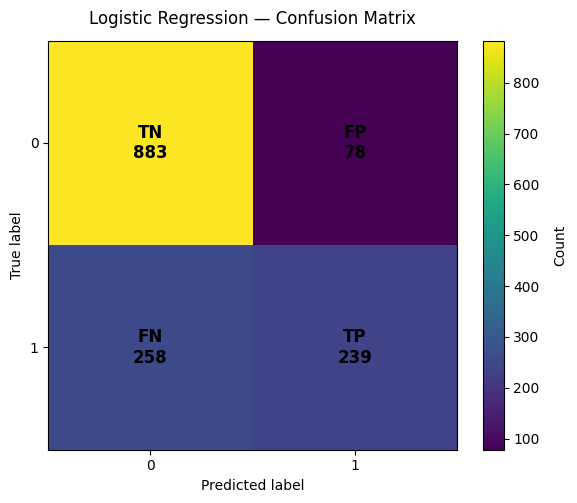

In [28]:
cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_logreg, cmap="viridis")

for i in range(cm_logreg.shape[0]):
    for j in range(cm_logreg.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_logreg[i, j]}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
            fontweight="bold",
        )

ax.set_title("Logistic Regression — Confusion Matrix", pad=12)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_yticklabels(["0", "1"])

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Count", rotation=90, labelpad=10)

plt.tight_layout()
plt.show()

The confusion matrix shows that the logistic regression baseline identifies the negative class more reliably than the positive class. False positives remain relatively limited, but the number of false negatives is noticeably higher.

This pattern suggests that, under the default classification threshold, the model behaves conservatively when assigning the positive class. In practical terms, it captures part of the short-sleep signal, but still misses a substantial share of participants who actually belong to the positive class.

In [37]:
tn_logreg, fp_logreg, fn_logreg, tp_logreg = confusion_matrix(y_test, y_test_pred_logreg).ravel()

logreg_confusion_summary = pd.DataFrame(
    {
        "model": ["logistic_regression"],
        "tn": [tn_logreg],
        "fp": [fp_logreg],
        "fn": [fn_logreg],
        "tp": [tp_logreg],
    }
)

logreg_confusion_summary

,model,tn,fp,fn,tp
0,logistic_regression,883,78,258,239


### 10.8 ROC curve for the logistic regression baseline

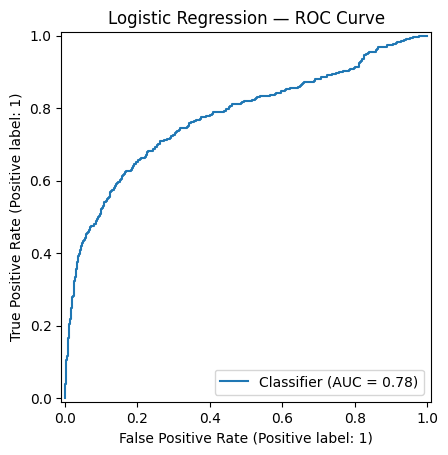

In [29]:
RocCurveDisplay.from_predictions(y_test, y_test_proba_logreg)
plt.title("Logistic Regression — ROC Curve")
plt.show()

The ROC curve indicates that the logistic regression baseline achieves a moderate level of class discrimination. Its ROC AUC suggests that the model captures a meaningful signal beyond chance, although its ranking performance remains far from optimal.

The curve is not especially smooth, which is not unusual in a finite test sample. At this stage, the main conclusion is not visual elegance but the fact that the linear baseline provides a credible discriminative starting point for subsequent model comparison.

### 10.9 Precision-recall curve for the logistic regression baseline

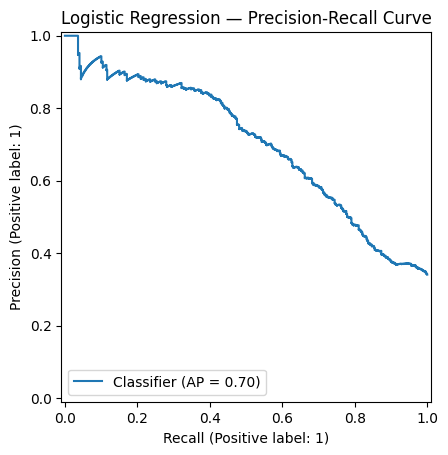

In [30]:
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_logreg)
plt.title("Logistic Regression — Precision-Recall Curve")
plt.show()

### 10.10 First reading of the precision-recall curve

The precision-recall curve suggests that the logistic regression baseline captures a meaningful signal for the positive class. Precision remains relatively strong across a broad portion of the recall range before declining more clearly at higher recall levels.

This pattern is consistent with a model that can rank many positive cases reasonably well, even if the default classification threshold remains somewhat conservative. In other words, the classifier appears more informative than the confusion matrix alone might initially suggest, particularly when performance is evaluated through predicted probabilities rather than only through hard class assignments.

### 10.11 Calibration curve for the logistic regression baseline

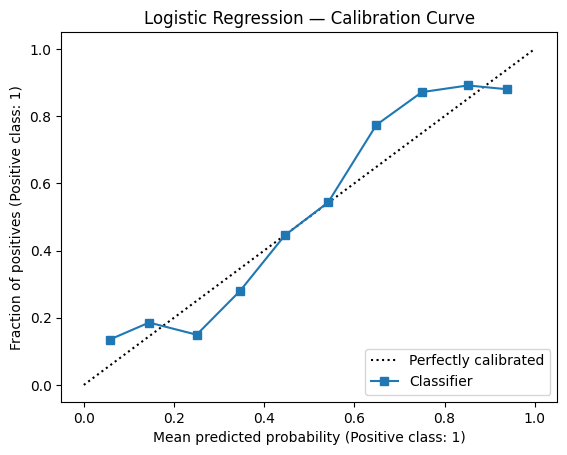

In [31]:
CalibrationDisplay.from_predictions(y_test, y_test_proba_logreg, n_bins=10)
plt.title("Logistic Regression — Calibration Curve")
plt.show()

## 11. Model 2 — Random forest baseline

Random forest is included as the first non-linear ensemble baseline in the project.

Its role is to test whether a tree-based model can recover predictive structure and feature interactions that may be difficult for a linear classifier to capture. This makes it a useful complement to logistic regression in the first benchmark stage.

As with the linear baseline, the goal here is not aggressive optimization, but a disciplined first estimate of how a more flexible model family behaves under the current feature specification.

### 11.1 Build and fit the random forest baseline

In [33]:
rf_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random forest baseline fitted successfully.")

Random forest baseline fitted successfully.


### 11.2 Generate predictions and compute baseline metrics

In [34]:
y_test_pred_rf = rf_pipeline.predict(X_test)
y_test_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_rf),
    "precision": precision_score(y_test, y_test_pred_rf),
    "recall": recall_score(y_test, y_test_pred_rf),
    "f1": f1_score(y_test, y_test_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_test_proba_rf),
    "pr_auc": average_precision_score(y_test, y_test_proba_rf),
    "brier_score": brier_score_loss(y_test, y_test_proba_rf),
}

rf_metrics_df = (
    pd.Series(rf_metrics, name="random_forest")
    .round(4)
    .to_frame()
)

rf_metrics_df

,random_forest
accuracy,0.7826
balanced_accuracy,0.7059
precision,0.8191
recall,0.4648
f1,0.5931
roc_auc,0.8040
pr_auc,0.7314
brier_score,0.1584


### 11.3 Diagnostic plots for the random forest baseline

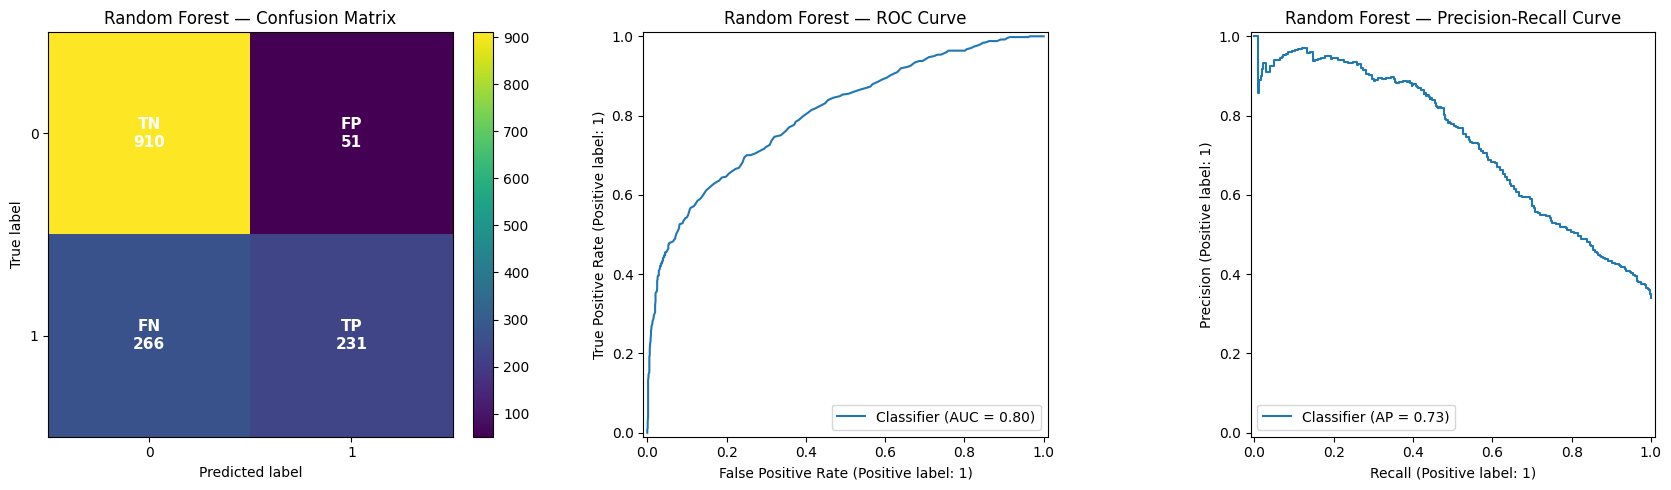

In [35]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_rf, cmap="viridis")
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_rf[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("Random Forest — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_rf, ax=axes[1])
axes[1].set_title("Random Forest — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_rf, ax=axes[2])
axes[2].set_title("Random Forest — Precision-Recall Curve")

plt.tight_layout()
plt.show()

### 11.4 Store the random forest confusion summary

In [36]:
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_test_pred_rf).ravel()

rf_confusion_summary = pd.DataFrame(
    {
        "model": ["random_forest"],
        "tn": [tn_rf],
        "fp": [fp_rf],
        "fn": [fn_rf],
        "tp": [tp_rf],
    }
)

rf_confusion_summary

,model,tn,fp,fn,tp
0,random_forest,910,51,266,231


## 12. Model 3 — HistGradientBoosting baseline

HistGradientBoostingClassifier is included as the boosting-based baseline in the first benchmark stage.

Its role is to test whether a more flexible additive tree model can recover predictive structure beyond what is captured by the linear baseline and the random forest baseline. This makes it a useful third reference point in a tabular classification problem where non-linear effects and interactions may be present.

At this stage, the objective remains disciplined benchmarking rather than aggressive tuning. The model is therefore introduced as a strong but still reasonably standard baseline within the sklearn ecosystem.

### 12.1 Build and fit the HistGradientBoosting baseline

In [38]:
hgb_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=42,
            ),
        ),
    ]
)

hgb_pipeline.fit(X_train, y_train)

print("HistGradientBoosting baseline fitted successfully.")

HistGradientBoosting baseline fitted successfully.


### 12.2 Generate predictions and compute baseline metrics

In [39]:
y_test_pred_hgb = hgb_pipeline.predict(X_test)
y_test_proba_hgb = hgb_pipeline.predict_proba(X_test)[:, 1]

hgb_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_hgb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_hgb),
    "precision": precision_score(y_test, y_test_pred_hgb),
    "recall": recall_score(y_test, y_test_pred_hgb),
    "f1": f1_score(y_test, y_test_pred_hgb),
    "roc_auc": roc_auc_score(y_test, y_test_proba_hgb),
    "pr_auc": average_precision_score(y_test, y_test_proba_hgb),
    "brier_score": brier_score_loss(y_test, y_test_proba_hgb),
}

hgb_metrics_df = (
    pd.Series(hgb_metrics, name="hist_gradient_boosting")
    .round(4)
    .to_frame()
)

hgb_metrics_df

,hist_gradient_boosting
accuracy,0.7853
balanced_accuracy,0.7245
precision,0.7659
recall,0.5332
f1,0.6287
roc_auc,0.8054
pr_auc,0.7215
brier_score,0.1572


### 12.3 Diagnostic plots for the HistGradientBoosting baseline

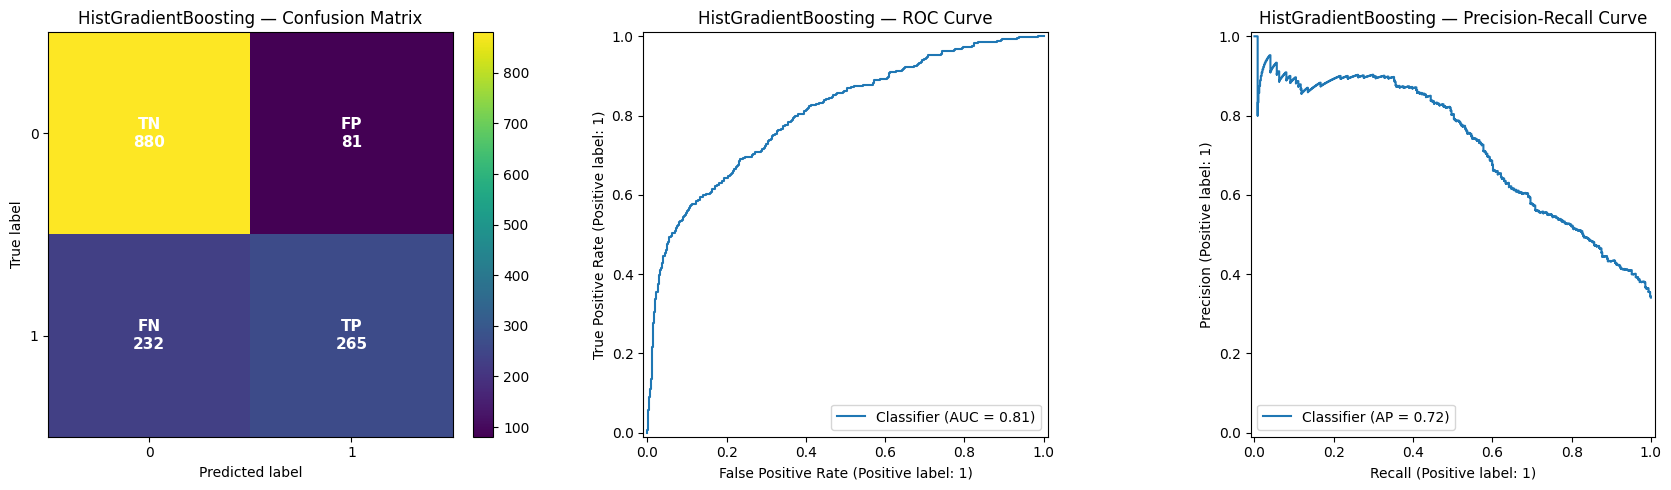

In [40]:
cm_hgb = confusion_matrix(y_test, y_test_pred_hgb)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_hgb, cmap="viridis")
for i in range(cm_hgb.shape[0]):
    for j in range(cm_hgb.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_hgb[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("HistGradientBoosting — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_hgb, ax=axes[1])
axes[1].set_title("HistGradientBoosting — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_hgb, ax=axes[2])
axes[2].set_title("HistGradientBoosting — Precision-Recall Curve")

plt.tight_layout()
plt.show()

### 12.4 Store the HistGradientBoosting confusion summary

In [41]:
tn_hgb, fp_hgb, fn_hgb, tp_hgb = confusion_matrix(y_test, y_test_pred_hgb).ravel()

hgb_confusion_summary = pd.DataFrame(
    {
        "model": ["hist_gradient_boosting"],
        "tn": [tn_hgb],
        "fp": [fp_hgb],
        "fn": [fn_hgb],
        "tp": [tp_hgb],
    }
)

hgb_confusion_summary

,model,tn,fp,fn,tp
0,hist_gradient_boosting,880,81,232,265


## 13. Comparative evaluation of baseline models

This section compares the three baseline model families under the same evaluation framework.

The purpose is not only to rank models mechanically, but to inspect where they differ in discrimination, class balance, positive-class recovery, and probability quality. This provides a more defensible basis for provisional model selection than relying on a single metric in isolation.

### 13.1 Build the comparative metrics table

In [42]:
baseline_metrics_comparison = pd.concat(
    [
        logreg_metrics_df.T.rename(index={"logistic_regression": "logistic_regression"}),
        rf_metrics_df.T.rename(index={"random_forest": "random_forest"}),
        hgb_metrics_df.T.rename(index={"hist_gradient_boosting": "hist_gradient_boosting"}),
    ],
    axis=0,
)

baseline_metrics_comparison = baseline_metrics_comparison[
    [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "brier_score",
    ]
].round(4)

baseline_metrics_comparison

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
logistic_regression,0.7695,0.6999,0.7539,0.4809,0.5872,0.7754,0.7025,0.1697
random_forest,0.7826,0.7059,0.8191,0.4648,0.5931,0.8040,0.7314,0.1584
hist_gradient_boosting,0.7853,0.7245,0.7659,0.5332,0.6287,0.8054,0.7215,0.1572


### 13.2 Build the comparative confusion summary table

In [43]:
baseline_confusion_comparison = pd.concat(
    [
        logreg_confusion_summary,
        rf_confusion_summary,
        hgb_confusion_summary,
    ],
    axis=0,
    ignore_index=True,
)

baseline_confusion_comparison

,model,tn,fp,fn,tp
0,logistic_regression,883,78,258,239
1,random_forest,910,51,266,231
2,hist_gradient_boosting,880,81,232,265


### 13.4 First reading of the confusion summary table

The confusion summary adds an important layer of interpretation because it makes the practical error profile of each model explicit. Aggregate metrics such as ROC AUC, F1 score, or balanced accuracy are useful for ranking models at a high level, but the confusion table shows more directly what each classifier is doing when it must assign hard class labels.

The logistic regression baseline occupies an intermediate position. Its number of false positives remains relatively limited, but it still misses a substantial number of true short sleepers, as reflected in its false negative count. This matches the broader picture seen in the earlier diagnostics: the linear baseline captures meaningful signal, but under the default threshold it remains somewhat conservative when assigning the positive class. In practical terms, it works as a credible reference model, although not as the strongest performer once more flexible model families are introduced.

The random forest baseline exhibits the most conservative positive-class behavior among the three models. It produces the smallest number of false positives, which is consistent with its stronger precision. In other words, when the random forest predicts `short_sleep = 1`, it does so more selectively and with fewer incorrect positive calls. However, this comes with a clear trade-off: it also produces the highest number of false negatives and the lowest number of true positives. The model is therefore stricter about assigning the positive class, but it leaves more true short sleepers undetected. From an analytical perspective, random forest is attractive if the main priority is to reduce false alarms and maintain a more cautious classifier, even at the cost of lower sensitivity.

HistGradientBoostingClassifier shows the opposite balance. It identifies the largest number of true positive cases and yields the lowest number of false negatives, which is exactly what would be expected from its stronger recall, F1 score, and balanced accuracy. This indicates that the boosting baseline is more effective at recovering the positive class under the current feature space. The cost of this improvement is a modest increase in false positives relative to random forest. In other words, HGB is willing to label more participants as short sleepers, and while that leads to a few more incorrect positive calls, it also allows the model to capture substantially more of the true positive signal.

This comparison is useful because it shows that the three baselines are not merely better or worse in the abstract; they are making different kinds of mistakes. Logistic regression provides a disciplined linear reference, random forest favors caution and positive-class precision, and HistGradientBoosting favors stronger recovery of true short sleepers while preserving competitive overall performance.

From a decision-oriented perspective, the preferred model depends on what type of error is considered more acceptable in the context of the project. If the priority were to minimize false positive alerts and apply a stricter standard before labeling someone as belonging to the positive class, random forest would have a defensible case. If, however, the project places greater value on not overlooking participants who truly belong to the `short_sleep` group, then HistGradientBoosting becomes the more attractive option because it reduces false negatives and increases true positive recovery.

Under the current analytical framing of MORPHEUS, HistGradientBoosting appears to offer the strongest overall compromise. It does not dominate random forest on every individual criterion, but it provides the most balanced combination of positive-class recovery, general discrimination, and overall predictive performance. For that reason, the confusion summary reinforces its status as the leading provisional candidate at this stage of the benchmark.

## 14. Provisional model selection

The first benchmark stage identifies HistGradientBoostingClassifier as the leading provisional candidate within the current modeling workflow.

This choice is not based on a single metric in isolation. Instead, it reflects the model's overall balance across discrimination, recall, F1 score, balanced accuracy, and probability quality. In particular, HistGradientBoosting achieves the strongest recovery of the positive class while remaining competitive in precision and overall calibration-related performance.

Random forest remains an important alternative because it offers a more conservative prediction profile, with fewer false positives and stronger precision. This makes it a defensible candidate when stricter positive-class assignment is preferred. However, under the current analytical framing of the project, the larger number of false negatives makes it less attractive as the main provisional model.

Logistic regression has fulfilled its role as a disciplined and interpretable linear baseline. It confirms that the current feature space contains meaningful predictive signal, but it is outperformed by the tree-based baselines across most of the main evaluation criteria.

At this stage, HistGradientBoosting should therefore be treated as the provisional benchmark leader, while random forest remains the strongest conservative alternative for the next round of model comparison.

## 15. Extended benchmark candidates

The first benchmark stage identified HistGradientBoostingClassifier as the leading provisional candidate and random forest as the strongest conservative alternative under the current feature space and default decision rule.

This second benchmark stage extends the comparison with additional tabular classifiers that are widely regarded as strong candidates in binary classification problems with mixed feature types and potentially non-linear structure. The goal is not to expand the model set indiscriminately, but to challenge the provisional leaders with a compact group of credible contenders.

To preserve a clear and disciplined workflow, this phase introduces four additional candidates: XGBoost, ExtraTrees, LightGBM, and CatBoost. Together, these models provide a stronger second-round benchmark against the leading models from the first stage, while keeping the comparison broad enough to reveal whether the provisional leaders remain competitive once more powerful tabular methods are introduced.

### 15.1 XGBoost

In [45]:
from xgboost import XGBClassifier

In [46]:
xgb_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)

print("XGBoost fitted successfully.")

XGBoost fitted successfully.


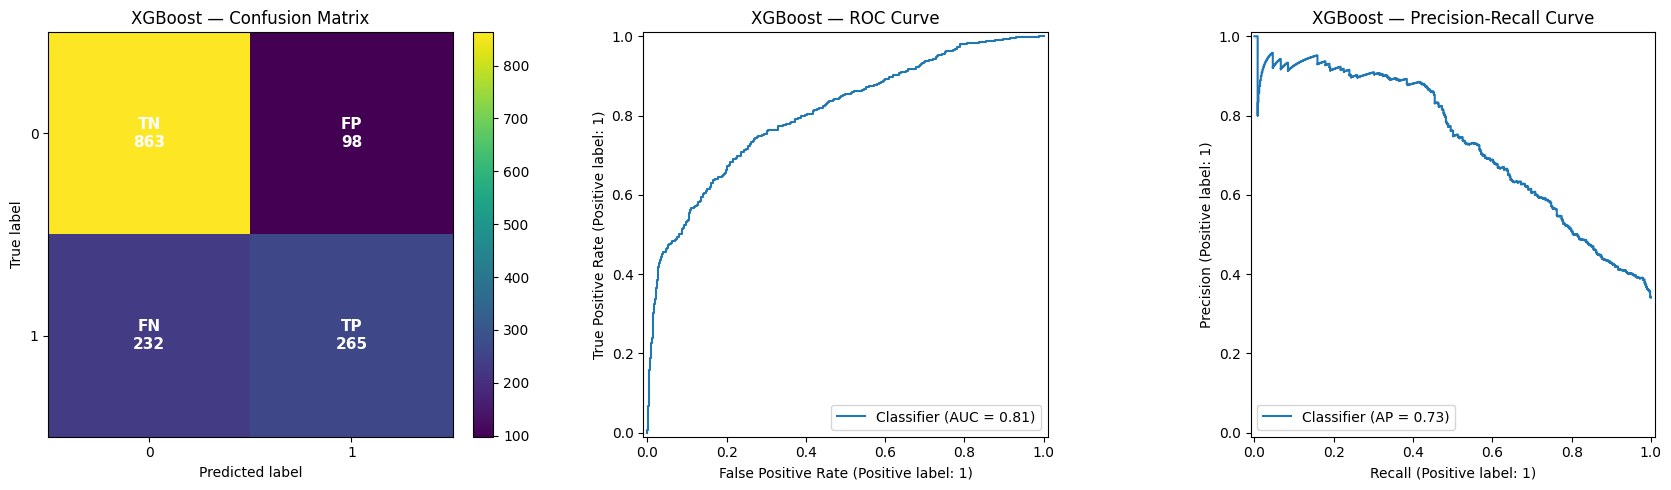

(                   xgboost
 accuracy            0.7737
 balanced_accuracy   0.7156
 precision           0.7300
 recall              0.5332
 f1                  0.6163
 roc_auc             0.8065
 pr_auc              0.7314
 brier_score         0.1571,
      model   tn  fp   fn   tp
 0  xgboost  863  98  232  265)

In [47]:
y_test_pred_xgb = xgb_pipeline.predict(X_test)
y_test_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_xgb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_xgb),
    "precision": precision_score(y_test, y_test_pred_xgb),
    "recall": recall_score(y_test, y_test_pred_xgb),
    "f1": f1_score(y_test, y_test_pred_xgb),
    "roc_auc": roc_auc_score(y_test, y_test_proba_xgb),
    "pr_auc": average_precision_score(y_test, y_test_proba_xgb),
    "brier_score": brier_score_loss(y_test, y_test_proba_xgb),
}

xgb_metrics_df = (
    pd.Series(xgb_metrics, name="xgboost")
    .round(4)
    .to_frame()
)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(y_test, y_test_pred_xgb).ravel()

xgb_confusion_summary = pd.DataFrame(
    {
        "model": ["xgboost"],
        "tn": [tn_xgb],
        "fp": [fp_xgb],
        "fn": [fn_xgb],
        "tp": [tp_xgb],
    }
)

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_xgb, cmap="viridis")
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_xgb[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("XGBoost — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_xgb, ax=axes[1])
axes[1].set_title("XGBoost — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_xgb, ax=axes[2])
axes[2].set_title("XGBoost — Precision-Recall Curve")

plt.tight_layout()
plt.show()

xgb_metrics_df, xgb_confusion_summary

### 15.2 ExtraTrees

In [48]:
from sklearn.ensemble import ExtraTreesClassifier

In [49]:
et_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

et_pipeline = Pipeline(
    steps=[
        ("preprocessor", et_preprocessor),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=400,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

et_pipeline.fit(X_train, y_train)

print("ExtraTrees fitted successfully.")

ExtraTrees fitted successfully.


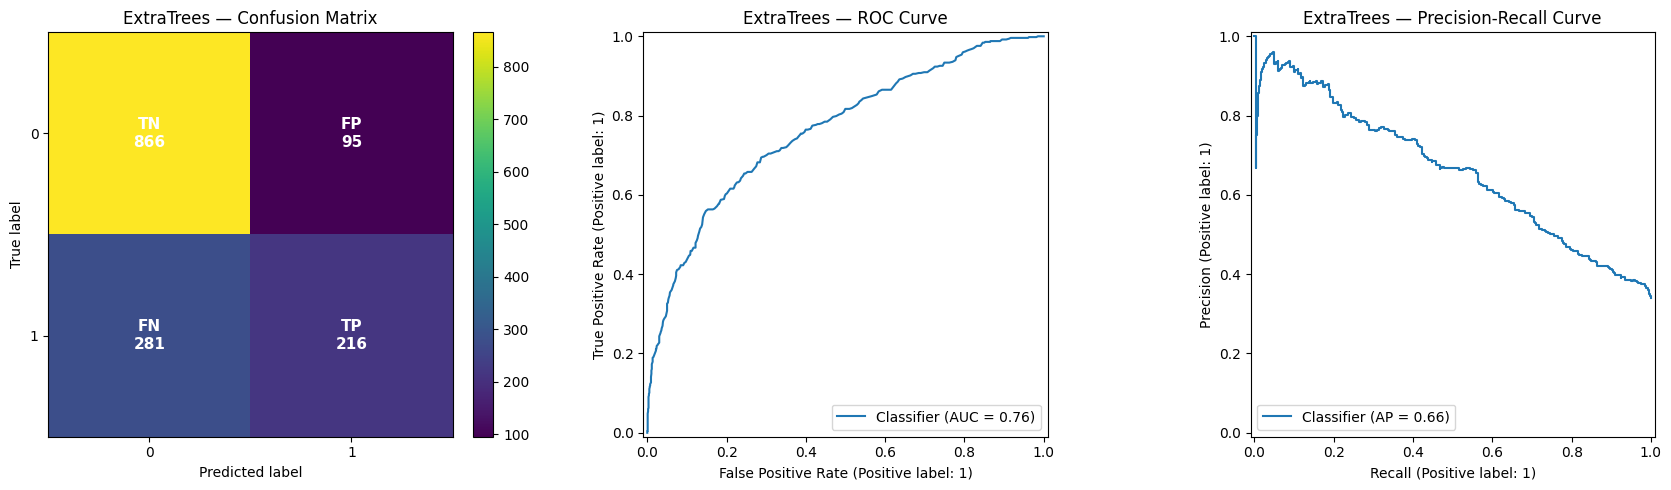

(                   extra_trees
 accuracy                0.7421
 balanced_accuracy       0.6679
 precision               0.6945
 recall                  0.4346
 f1                      0.5347
 roc_auc                 0.7641
 pr_auc                  0.6595
 brier_score             0.1799,
          model   tn  fp   fn   tp
 0  extra_trees  866  95  281  216)

In [50]:
y_test_pred_et = et_pipeline.predict(X_test)
y_test_proba_et = et_pipeline.predict_proba(X_test)[:, 1]

et_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_et),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_et),
    "precision": precision_score(y_test, y_test_pred_et),
    "recall": recall_score(y_test, y_test_pred_et),
    "f1": f1_score(y_test, y_test_pred_et),
    "roc_auc": roc_auc_score(y_test, y_test_proba_et),
    "pr_auc": average_precision_score(y_test, y_test_proba_et),
    "brier_score": brier_score_loss(y_test, y_test_proba_et),
}

et_metrics_df = (
    pd.Series(et_metrics, name="extra_trees")
    .round(4)
    .to_frame()
)

tn_et, fp_et, fn_et, tp_et = confusion_matrix(y_test, y_test_pred_et).ravel()

et_confusion_summary = pd.DataFrame(
    {
        "model": ["extra_trees"],
        "tn": [tn_et],
        "fp": [fp_et],
        "fn": [fn_et],
        "tp": [tp_et],
    }
)

cm_et = confusion_matrix(y_test, y_test_pred_et)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_et, cmap="viridis")
for i in range(cm_et.shape[0]):
    for j in range(cm_et.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_et[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("ExtraTrees — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_et, ax=axes[1])
axes[1].set_title("ExtraTrees — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_et, ax=axes[2])
axes[2].set_title("ExtraTrees — Precision-Recall Curve")

plt.tight_layout()
plt.show()

et_metrics_df, et_confusion_summary

### 15.3 LightGBM

In [52]:
from lightgbm import LGBMClassifier

In [53]:
lgbm_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", lgbm_preprocessor),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

lgbm_pipeline.fit(X_train, y_train)

print("LightGBM fitted successfully.")

LightGBM fitted successfully.


f:\DOCUMENTOS\CIENCIA DE DATOS\portfolio-data-science\morpheus-sleep-health-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\DOCUMENTOS\CIENCIA DE DATOS\portfolio-data-science\morpheus-sleep-health-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


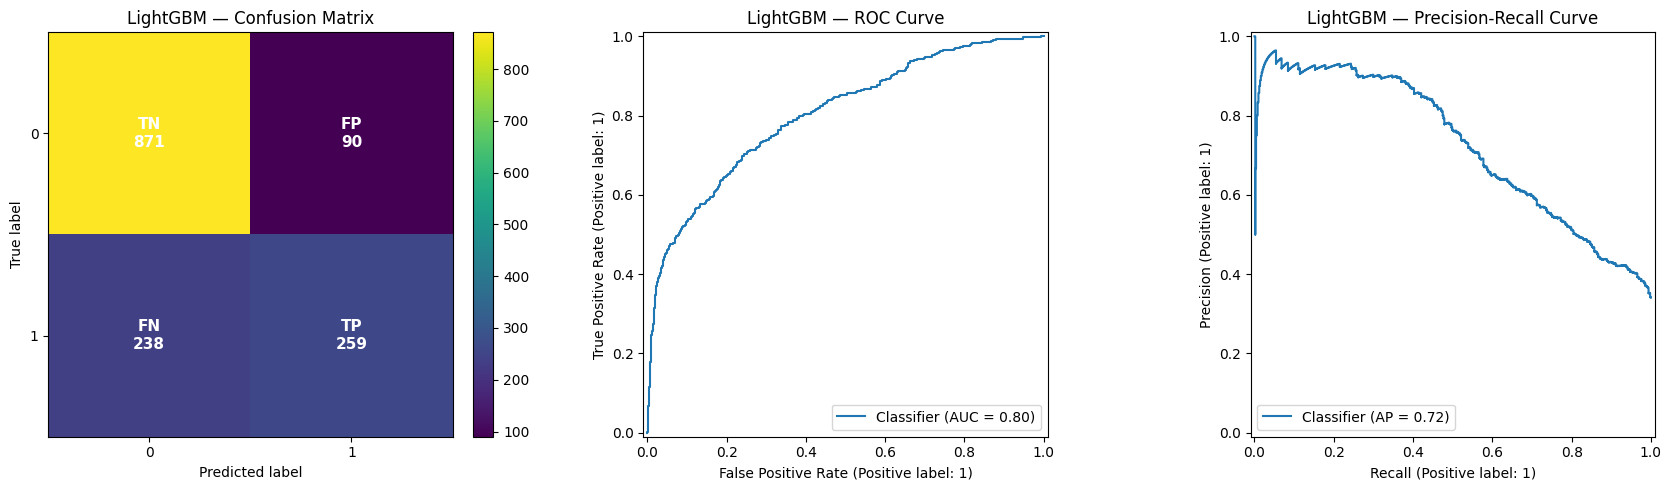

(                   lightgbm
 accuracy             0.7750
 balanced_accuracy    0.7137
 precision            0.7421
 recall               0.5211
 f1                   0.6123
 roc_auc              0.8032
 pr_auc               0.7234
 brier_score          0.1597,
       model   tn  fp   fn   tp
 0  lightgbm  871  90  238  259)

In [54]:
y_test_pred_lgbm = lgbm_pipeline.predict(X_test)
y_test_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

lgbm_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_lgbm),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_lgbm),
    "precision": precision_score(y_test, y_test_pred_lgbm),
    "recall": recall_score(y_test, y_test_pred_lgbm),
    "f1": f1_score(y_test, y_test_pred_lgbm),
    "roc_auc": roc_auc_score(y_test, y_test_proba_lgbm),
    "pr_auc": average_precision_score(y_test, y_test_proba_lgbm),
    "brier_score": brier_score_loss(y_test, y_test_proba_lgbm),
}

lgbm_metrics_df = (
    pd.Series(lgbm_metrics, name="lightgbm")
    .round(4)
    .to_frame()
)

tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = confusion_matrix(y_test, y_test_pred_lgbm).ravel()

lgbm_confusion_summary = pd.DataFrame(
    {
        "model": ["lightgbm"],
        "tn": [tn_lgbm],
        "fp": [fp_lgbm],
        "fn": [fn_lgbm],
        "tp": [tp_lgbm],
    }
)

cm_lgbm = confusion_matrix(y_test, y_test_pred_lgbm)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_lgbm, cmap="viridis")
for i in range(cm_lgbm.shape[0]):
    for j in range(cm_lgbm.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_lgbm[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("LightGBM — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_lgbm, ax=axes[1])
axes[1].set_title("LightGBM — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_lgbm, ax=axes[2])
axes[2].set_title("LightGBM — Precision-Recall Curve")

plt.tight_layout()
plt.show()

lgbm_metrics_df, lgbm_confusion_summary

### 15.4 CatBoost

In [55]:
from catboost import CatBoostClassifier

In [56]:
cb_preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    config={
        **config,
        "preprocessing": {
            "numeric": {
                "imputer_strategy": config["preprocessing"]["numeric"]["imputer_strategy"],
                "scaler": "none",
            },
            "categorical": config["preprocessing"]["categorical"],
        },
    },
)

cb_pipeline = Pipeline(
    steps=[
        ("preprocessor", cb_preprocessor),
        (
            "model",
            CatBoostClassifier(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                loss_function="Logloss",
                eval_metric="AUC",
                random_state=42,
                verbose=0,
            ),
        ),
    ]
)

cb_pipeline.fit(X_train, y_train)

print("CatBoost fitted successfully.")

CatBoost fitted successfully.


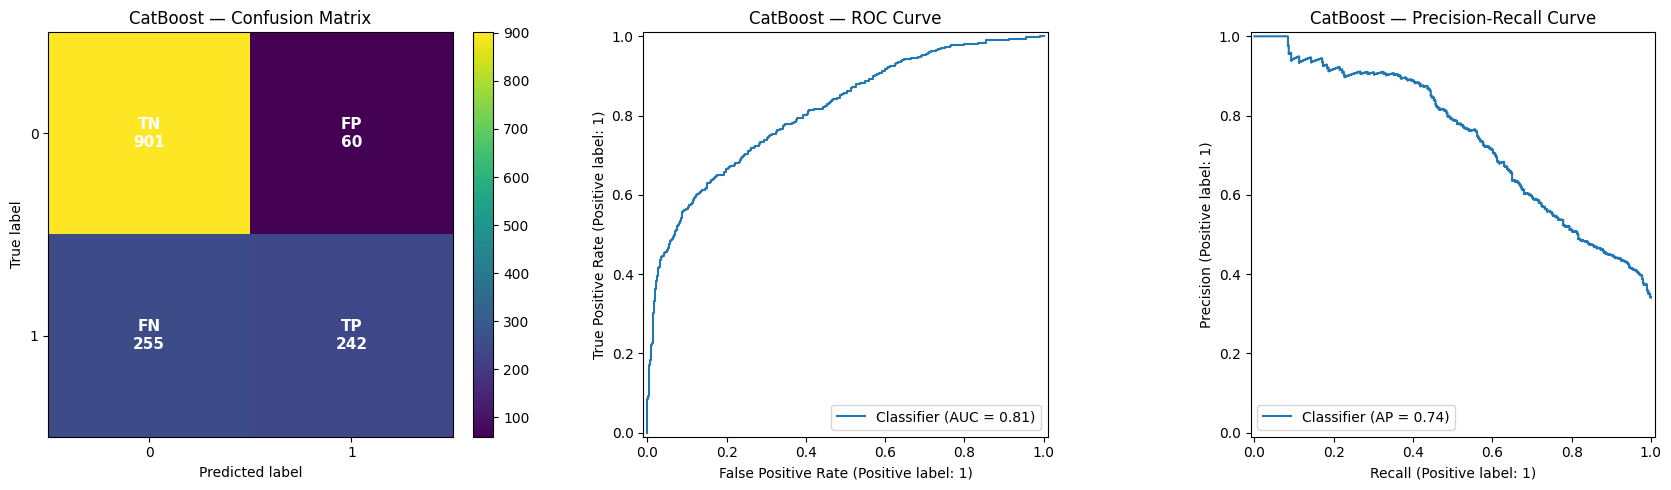

(                   catboost
 accuracy             0.7840
 balanced_accuracy    0.7122
 precision            0.8013
 recall               0.4869
 f1                   0.6058
 roc_auc              0.8127
 pr_auc               0.7430
 brier_score          0.1535,
       model   tn  fp   fn   tp
 0  catboost  901  60  255  242)

In [57]:
y_test_pred_cb = cb_pipeline.predict(X_test)
y_test_proba_cb = cb_pipeline.predict_proba(X_test)[:, 1]

cb_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_cb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred_cb),
    "precision": precision_score(y_test, y_test_pred_cb),
    "recall": recall_score(y_test, y_test_pred_cb),
    "f1": f1_score(y_test, y_test_pred_cb),
    "roc_auc": roc_auc_score(y_test, y_test_proba_cb),
    "pr_auc": average_precision_score(y_test, y_test_proba_cb),
    "brier_score": brier_score_loss(y_test, y_test_proba_cb),
}

cb_metrics_df = (
    pd.Series(cb_metrics, name="catboost")
    .round(4)
    .to_frame()
)

tn_cb, fp_cb, fn_cb, tp_cb = confusion_matrix(y_test, y_test_pred_cb).ravel()

cb_confusion_summary = pd.DataFrame(
    {
        "model": ["catboost"],
        "tn": [tn_cb],
        "fp": [fp_cb],
        "fn": [fn_cb],
        "tp": [tp_cb],
    }
)

cm_cb = confusion_matrix(y_test, y_test_pred_cb)

cm_labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
im = axes[0].imshow(cm_cb, cmap="viridis")
for i in range(cm_cb.shape[0]):
    for j in range(cm_cb.shape[1]):
        axes[0].text(
            j,
            i,
            f"{cm_labels[i, j]}\n{cm_cb[i, j]}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
axes[0].set_title("CatBoost — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_proba_cb, ax=axes[1])
axes[1].set_title("CatBoost — ROC Curve")

# Precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_cb, ax=axes[2])
axes[2].set_title("CatBoost — Precision-Recall Curve")

plt.tight_layout()
plt.show()

cb_metrics_df, cb_confusion_summary

## 16. Comparative evaluation — extended benchmark

This section consolidates the results of both benchmark stages into a single comparative view.

The objective is not only to rank models mechanically, but to examine how the initial baselines and the new challengers differ in discrimination, positive-class recovery, overall balance, and practical error profile. This extended comparison provides the basis for selecting the small group of finalists that will move forward to refinement, threshold analysis, and later hyperparameter tuning.

### 16.1 Build the extended comparative metrics table

In [58]:
extended_metrics_comparison = pd.concat(
    [
        logreg_metrics_df.T,
        rf_metrics_df.T,
        hgb_metrics_df.T,
        xgb_metrics_df.T,
        et_metrics_df.T,
        lgbm_metrics_df.T,
        cb_metrics_df.T,
    ],
    axis=0,
)

extended_metrics_comparison = extended_metrics_comparison[
    [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "brier_score",
    ]
].round(4)

extended_metrics_comparison

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
logistic_regression,0.7695,0.6999,0.7539,0.4809,0.5872,0.7754,0.7025,0.1697
random_forest,0.7826,0.7059,0.8191,0.4648,0.5931,0.8040,0.7314,0.1584
hist_gradient_boosting,0.7853,0.7245,0.7659,0.5332,0.6287,0.8054,0.7215,0.1572
xgboost,0.7737,0.7156,0.7300,0.5332,0.6163,0.8065,0.7314,0.1571
extra_trees,0.7421,0.6679,0.6945,0.4346,0.5347,0.7641,0.6595,0.1799
lightgbm,0.7750,0.7137,0.7421,0.5211,0.6123,0.8032,0.7234,0.1597
catboost,0.7840,0.7122,0.8013,0.4869,0.6058,0.8127,0.7430,0.1535


### 16.2 Build the extended comparative confusion summary table

In [59]:
extended_confusion_comparison = pd.concat(
    [
        logreg_confusion_summary,
        rf_confusion_summary,
        hgb_confusion_summary,
        xgb_confusion_summary,
        et_confusion_summary,
        lgbm_confusion_summary,
        cb_confusion_summary,
    ],
    axis=0,
    ignore_index=True,
)

extended_confusion_comparison

,model,tn,fp,fn,tp
0,logistic_regression,883,78,258,239
1,random_forest,910,51,266,231
2,hist_gradient_boosting,880,81,232,265
3,xgboost,863,98,232,265
4,extra_trees,866,95,281,216
5,lightgbm,871,90,238,259
6,catboost,901,60,255,242


### 16.3 First reading of the extended benchmark

The extended benchmark confirms that the first-stage leaders remain competitive once stronger tabular candidates are introduced, but it also reveals a more nuanced finalist group than the initial comparison alone suggested.

HistGradientBoostingClassifier remains the strongest overall compromise under the current default decision rule. It achieves the best combination of accuracy, balanced accuracy, F1 score, and positive-class recovery, while maintaining competitive discrimination and probability quality. Its confusion profile also remains favorable, with the largest number of true positives and one of the lowest false negative counts in the full comparison.

XGBoost emerges as a particularly strong challenger. Its ROC AUC, precision-recall performance, and probability quality are all highly competitive, and its confusion profile matches HistGradientBoosting in true positives, recall, and false negatives. However, it reaches that level with a larger number of false positives, which suggests that its ranking ability is strong but that its default threshold may not yet be yielding the most balanced hard classification behavior.

CatBoost also deserves finalist status. It delivers the strongest ROC AUC, the strongest precision-recall score, and the best Brier score in the extended benchmark, which points to especially strong ranking and probability quality. At the same time, its hard classification behavior remains more conservative than HistGradientBoosting, with fewer true positives and more false negatives. This makes it an attractive contender if probability quality and precision are prioritized more heavily than maximum positive-class recovery.

By contrast, ExtraTrees falls behind the leading group across most major criteria, and logistic regression has already fulfilled its role as an interpretable linear baseline rather than a serious finalist. LightGBM remains competitive, but it does not clearly displace HistGradientBoosting, XGBoost, or CatBoost in the current benchmark. Random forest still provides the strongest conservative alternative, but under the present analytical framing it does not appear as compelling as the top three models for refinement.

Taken together, the extended benchmark suggests that HistGradientBoosting, XGBoost, and CatBoost should move forward as the finalist group for the next phase of the project.

## 17. Provisional finalists for refinement

The extended benchmark suggests that the most promising candidates under the current base feature space are HistGradientBoostingClassifier, XGBoost, and CatBoost.

These three models emerge as the strongest provisional finalists for different but complementary reasons. HistGradientBoosting provides the most balanced overall performance under the default decision rule, combining strong recall, F1 score, balanced accuracy, and overall classification stability. XGBoost matches HistGradientBoosting in positive-class recovery and remains highly competitive in discrimination and probability-related metrics, although its current threshold produces a somewhat larger number of false positives. CatBoost stands out for its ranking ability and probability quality, achieving the strongest ROC AUC, precision-recall score, and Brier score in the extended comparison.

Taken together, these results indicate that the project should move forward with a finalist group rather than with a single prematurely fixed winner. At this stage, HistGradientBoosting can still be regarded as the leading provisional candidate, but XGBoost and CatBoost remain strong enough to justify further evaluation before a final core model is selected.

Importantly, this finalist ranking should be interpreted as valid for the current post-EDA feature space, not yet as the final hierarchy of the project as a whole. Since no dedicated feature engineering stage has been introduced yet, the next iteration should focus on improving the feature representation and rerunning these finalists under the updated specification. Only after that second pass will it be methodologically appropriate to proceed to hyperparameter tuning and, later, threshold analysis on the tuned finalists.

## 18. Closing remarks and next iteration

This notebook established the first full modeling benchmark for MORPHEUS using the post-EDA base feature space. Under that representation, the results show that the strongest provisional finalists are HistGradientBoostingClassifier, XGBoost, and CatBoost.

At the same time, these results should not yet be interpreted as the final ranking of the project as a whole. The current comparison was conducted before any dedicated feature engineering stage, which means that the benchmark reflects model performance under the original analytical feature space rather than under a more fully developed representation of the problem.

For that reason, the next iteration of the workflow should not move directly into final hyperparameter tuning or threshold selection. Instead, the project should first explore a small set of analytically defensible engineered features and then rerun the finalist models on the updated feature space. Only after that second modeling pass will it be methodologically sound to proceed to model refinement through hyperparameter tuning and, finally, threshold analysis on the tuned finalists.

The next notebook therefore shifts the focus from model-family comparison to feature-space improvement. Its purpose will be to test whether a more expressive and better-structured representation of the available health, behavioral, anthropometric, and sleep-related variables can improve the performance and separation of the provisional finalists identified here.Ç